# JAX vs NumPy Gibbs Profiling: Logit & Negbin

This notebook profiles the JAX and NumPy Gibbs samplers for SAR-logit, SEM-logit, and SAR-Negative Binomial models, comparing wall-clock time, ESS, and posterior agreement.

## Architecture

Both backends use the same Gibbs structure (PG ω → ρ → β → α), but differ in the linear algebra and ρ-update strategy:

| Backend | ρ/λ update | Linear algebra | Key advantage |
|---------|-----------|---------------|---------------|
| **Gibbs-NumPy** (`factorize`) | Slice + Krylov | CHOLMOD/CG sparse solves | Exploits sparsity for large n |
| **Gibbs-JAX** (`jax_dense`) | Slice (all models) | Dense LU factorisation | Full JIT, no Python dispatch |

### Model-specific ρ/λ strategies

- **SAR/SEM-Logit** (JAX): Stepping-out + shrinkage slice sampling on the collapsed log-density. Each candidate needs only a forward density evaluation — no gradient required. This avoids the O(n³) forward + O(n³) backward cost of `jax.value_and_grad` through `jnp.linalg.solve` that made MALA 3.6× slower than NumPy.
- **SAR-NB reduced form** (both backends): Slice sampling with a shift-invert Krylov basis. The β-marginalised density needs $U = (I-\rho W)^{-1}X$; the Krylov basis builds U(ρ) as a Horner polynomial in Δρ, giving O(m·n·k) per candidate.

In [1]:
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from libpysal.graph import Graph

from bayespecon.dgp import simulate_sar_logit, simulate_sar_negbin, simulate_sem_logit
from bayespecon.models import SARNegativeBinomial, SARSpatialLogit, SEMSpatialLogit

try:
    import jax

    # Clear JAX JIT cache so code changes take effect without kernel restart
    jax.clear_caches()
    HAS_JAX = True
except ImportError:
    HAS_JAX = False

print(f"JAX available: {HAS_JAX}")

JAX available: True


## 1. Generate Synthetic Data

We use a 7×7 rook-contiguity lattice (n=49) with 3 regressors. Each model type generates data from its own DGP so the spatial parameter is well-identified.

In [2]:
SIDE = 7  # 7x7 grid → n=49
SEED = 42
DRAWS = 2000
TUNE = 1000
CHAINS = 4


def make_rook_W(side: int) -> np.ndarray:
    """Row-standardized rook-contiguity weights on a side x side grid."""
    n = side * side
    W = np.zeros((n, n))
    for r in range(side):
        for c in range(side):
            i = r * side + c
            if r > 0:
                W[i, (r - 1) * side + c] = 1
            if r < side - 1:
                W[i, (r + 1) * side + c] = 1
            if c > 0:
                W[i, r * side + (c - 1)] = 1
            if c < side - 1:
                W[i, r * side + (c + 1)] = 1
    row_sums = W.sum(axis=1, keepdims=True)
    return W / np.where(row_sums == 0, 1, row_sums)


def W_to_graph(W_dense: np.ndarray) -> Graph:
    """Convert a dense weight matrix to a libpysal Graph."""
    n = W_dense.shape[0]
    focal, neighbor, weight = [], [], []
    for i in range(n):
        for j in range(n):
            if W_dense[i, j] != 0:
                focal.append(i)
                neighbor.append(j)
                weight.append(W_dense[i, j])
    return Graph.from_arrays(
        np.array(focal),
        np.array(neighbor),
        np.array(weight, dtype=float),
    ).transform("r")


W_dense = make_rook_W(SIDE)
W = W_to_graph(W_dense)
n = SIDE * SIDE
print(f"n = {n}, W shape = {W_dense.shape}")

n = 49, W shape = (49, 49)


In [3]:
rng = np.random.default_rng(SEED)

# SAR-logit data
sar_logit_out = simulate_sar_logit(W=W_dense, rho=0.6, rng=rng)
y_sar_logit, X_sar_logit = sar_logit_out["y"], sar_logit_out["X"]

# SEM-logit data
sem_logit_out = simulate_sem_logit(W=W_dense, lam=0.6, rng=rng)
y_sem_logit, X_sem_logit = sem_logit_out["y"], sem_logit_out["X"]

# SAR-NB data
sar_nb_out = simulate_sar_negbin(
    n=n, rho=0.5, beta=np.array([2.0, 1.0, -0.5]), alpha=5.0, rng=rng, W=W_dense
)
y_sar_nb, X_sar_nb = sar_nb_out["y"], sar_nb_out["X"]

print(f"SAR-logit: y={y_sar_logit.shape}, X={X_sar_logit.shape}")
print(f"SEM-logit: y={y_sem_logit.shape}, X={X_sem_logit.shape}")
print(f"SAR-NB:    y={y_sar_nb.shape}, X={X_sar_nb.shape}")

SAR-logit: y=(49,), X=(49, 2)
SEM-logit: y=(49,), X=(49, 2)
SAR-NB:    y=(49,), X=(49, 3)


## 2. Define the Profiling Function

We time each sampler configuration and collect:
- **Wall-clock time** (seconds)
- **Posterior means** for key parameters
- **R-hat** and **ESS** diagnostics

In [4]:
def profile_model(model, sampler_config: dict, label: str) -> dict:
    """Fit a model with a given sampler config and return timing + diagnostics."""
    t0 = time.perf_counter()
    idata = model.fit(**sampler_config)
    elapsed = time.perf_counter() - t0

    # Extract spatial parameter name (rho for SAR, lam for SEM)
    spatial_vars = [p for p in idata.posterior.data_vars if p in ("rho", "lam")]
    spatial_param = spatial_vars[0] if spatial_vars else None

    result = {
        "label": label,
        "elapsed_s": round(elapsed, 2),
    }

    # Posterior means
    result["intercept_mean"] = float(
        idata.posterior["beta"].mean(dim=["chain", "draw"]).values[0]
    )
    if spatial_param:
        result[f"{spatial_param}_mean"] = float(idata.posterior[spatial_param].mean())

    # For NB, also report alpha and sigma
    if "alpha" in idata.posterior.data_vars:
        result["alpha_mean"] = float(idata.posterior["alpha"].mean())
    if "sigma" in idata.posterior.data_vars:
        result["sigma_mean"] = float(idata.posterior["sigma"].mean())

    # Diagnostics
    diag_vars = ["beta"] + ([spatial_param] if spatial_param else [])
    if "alpha" in idata.posterior.data_vars:
        diag_vars.append("alpha")
    if "sigma" in idata.posterior.data_vars:
        diag_vars.append("sigma")
    summary = az.summary(idata, var_names=diag_vars)
    result["rhat_max"] = round(float(summary["r_hat"].max()), 3)
    result["ess_bulk_min"] = int(summary["ess_bulk"].min())

    return result

## 3. Profile All Models

We profile each of the 3 models under 2 Gibbs configurations:

| Config | Backend | ρ/λ update | Linear algebra |
|--------|---------|-----------|---------------|
| Gibbs-NumPy | `factorize` | Slice + Krylov | CHOLMOD/CG sparse |
| Gibbs-JAX | `jax_dense` | Slice (all models) | Dense LU |

In [5]:
COMMON = dict(
    draws=DRAWS, tune=TUNE, chains=CHAINS, random_seed=SEED, progressbar=False
)

configs = {
    "Gibbs-NumPy": dict(sampler="gibbs", gibbs_method="factorize", n_jobs=-1, **COMMON),
}

if HAS_JAX:
    configs["Gibbs-JAX"] = dict(sampler="gibbs", gibbs_method="jax_dense", **COMMON)

print(f"Configs: {list(configs.keys())}")

Configs: ['Gibbs-NumPy', 'Gibbs-JAX']


In [6]:
results = []

models_and_data = [
    ("SAR-Logit", SARSpatialLogit, y_sar_logit, X_sar_logit),
    ("SEM-Logit", SEMSpatialLogit, y_sem_logit, X_sem_logit),
    ("SAR-NB", SARNegativeBinomial, y_sar_nb, X_sar_nb),
]

for model_name, ModelClass, y, X in models_and_data:
    print(f"\n{'=' * 60}")
    print(f"Model: {model_name}")
    print(f"{'=' * 60}")

    for config_name, config in configs.items():
        label = f"{model_name}/{config_name}"
        print(f"  Running {label}...", end=" ", flush=True)

        model = ModelClass(y=y, X=X, W=W)
        try:
            result = profile_model(model, config, label)
            spatial_key = (
                "rho_mean"
                if "rho_mean" in result
                else ("lam_mean" if "lam_mean" in result else None)
            )
            spatial_val = result.get(spatial_key, "N/A")
            if isinstance(spatial_val, float):
                spatial_val = f"{spatial_val:.4f}"
            print(
                f"{result['elapsed_s']:.1f}s  ρ̂/λ̂={spatial_val}  r̂={result['rhat_max']:.3f}  ESS={result['ess_bulk_min']}"
            )
        except Exception as e:
            result = {"label": label, "elapsed_s": None, "error": str(e)}
            print(f"FAILED: {e}")

        results.append(result)

print(f"\nDone! {len(results)} configurations profiled.")


Model: SAR-Logit
  Running SAR-Logit/Gibbs-NumPy... 8.1s  ρ̂/λ̂=0.0330  r̂=1.000  ESS=482
  Running SAR-Logit/Gibbs-JAX... 5.6s  ρ̂/λ̂=0.0384  r̂=1.010  ESS=491

Model: SEM-Logit
  Running SEM-Logit/Gibbs-NumPy... 7.7s  ρ̂/λ̂=0.0499  r̂=1.010  ESS=572
  Running SEM-Logit/Gibbs-JAX... 4.7s  ρ̂/λ̂=0.0620  r̂=1.010  ESS=514

Model: SAR-NB
  Running SAR-NB/Gibbs-NumPy... 8.7s  ρ̂/λ̂=0.4288  r̂=1.000  ESS=1217
  Running SAR-NB/Gibbs-JAX... 11.0s  ρ̂/λ̂=0.4240  r̂=1.000  ESS=1152

Done! 6 configurations profiled.


## 4. Results Summary

In [7]:
# Build a clean results DataFrame
rows = []
for r in results:
    if "error" in r:
        rows.append(
            {"Model/Sampler": r["label"], "Time (s)": None, "Error": r["error"]}
        )
        continue
    model_name, config_name = r["label"].split("/")
    spatial_key = (
        "rho_mean" if "rho_mean" in r else ("lam_mean" if "lam_mean" in r else None)
    )
    row = {
        "Model": model_name,
        "Sampler": config_name,
        "Time (s)": r["elapsed_s"],
        "Intercept": round(r["intercept_mean"], 4),
        "ρ̂/λ̂": round(r.get(spatial_key, float("nan")), 4) if spatial_key else None,
        "max R̂": r["rhat_max"],
        "min ESS": r["ess_bulk_min"],
    }
    if "alpha_mean" in r:
        row["α̂"] = round(r["alpha_mean"], 4)
    if "sigma_mean" in r:
        row["σ̂"] = round(r["sigma_mean"], 4)
    rows.append(row)

df = pd.DataFrame(rows)
df = df.drop_duplicates(subset=["Model", "Sampler"], keep="last")
df.style.format(
    {
        "Time (s)": "{:.1f}",
        "Intercept": "{:.4f}",
        "ρ̂/λ̂": "{:.4f}",
        "α̂": "{:.2f}",
        "σ̂": "{:.4f}",
    }
)

,Model,Sampler,Time (s),Intercept,ρ̂/λ̂,max R̂,min ESS,α̂
0,SAR-Logit,Gibbs-NumPy,8.1,0.5071,0.0330,1.000000,482,nan
1,SAR-Logit,Gibbs-JAX,5.6,0.5167,0.0384,1.010000,491,nan
2,SEM-Logit,Gibbs-NumPy,7.7,-0.1881,0.0499,1.010000,572,nan
3,SEM-Logit,Gibbs-JAX,4.7,-0.1847,0.0620,1.010000,514,nan
4,SAR-NB,Gibbs-NumPy,8.7,2.1803,0.4288,1.000000,1217,4.77
5,SAR-NB,Gibbs-JAX,11.0,2.1987,0.4240,1.000000,1152,4.78


## 5. Speedup Comparison

How much faster is the JAX path compared to NumPy (slice)?

In [8]:
# Pivot to compare times
if len(df) > 0 and "Time (s)" in df.columns:
    pivot = df.drop_duplicates(subset=["Model", "Sampler"], keep="last").pivot(
        index="Model", columns="Sampler", values="Time (s)"
    )
    if "Gibbs-NumPy" in pivot.columns and "Gibbs-JAX" in pivot.columns:
        pivot["JAX/NumPy ratio"] = pivot["Gibbs-JAX"] / pivot["Gibbs-NumPy"]
        pivot["JAX speedup"] = pivot["Gibbs-NumPy"] / pivot["Gibbs-JAX"]
        print("Speedup of JAX over NumPy (slice):")
        display(pivot.round(2))
    else:
        display(pivot.round(2))
else:
    print("No results to display.")

Speedup of JAX over NumPy (slice):


Sampler,Gibbs-JAX,Gibbs-NumPy,JAX/NumPy ratio,JAX speedup
Model,,,,
SAR-Logit,5.61,8.09,0.69,1.44
SAR-NB,11.01,8.66,1.27,0.79
SEM-Logit,4.67,7.68,0.61,1.64


## 6. Posterior Comparison

Compare posterior distributions across backends for each model. The JAX and NumPy posteriors should agree closely for well-identified parameters.

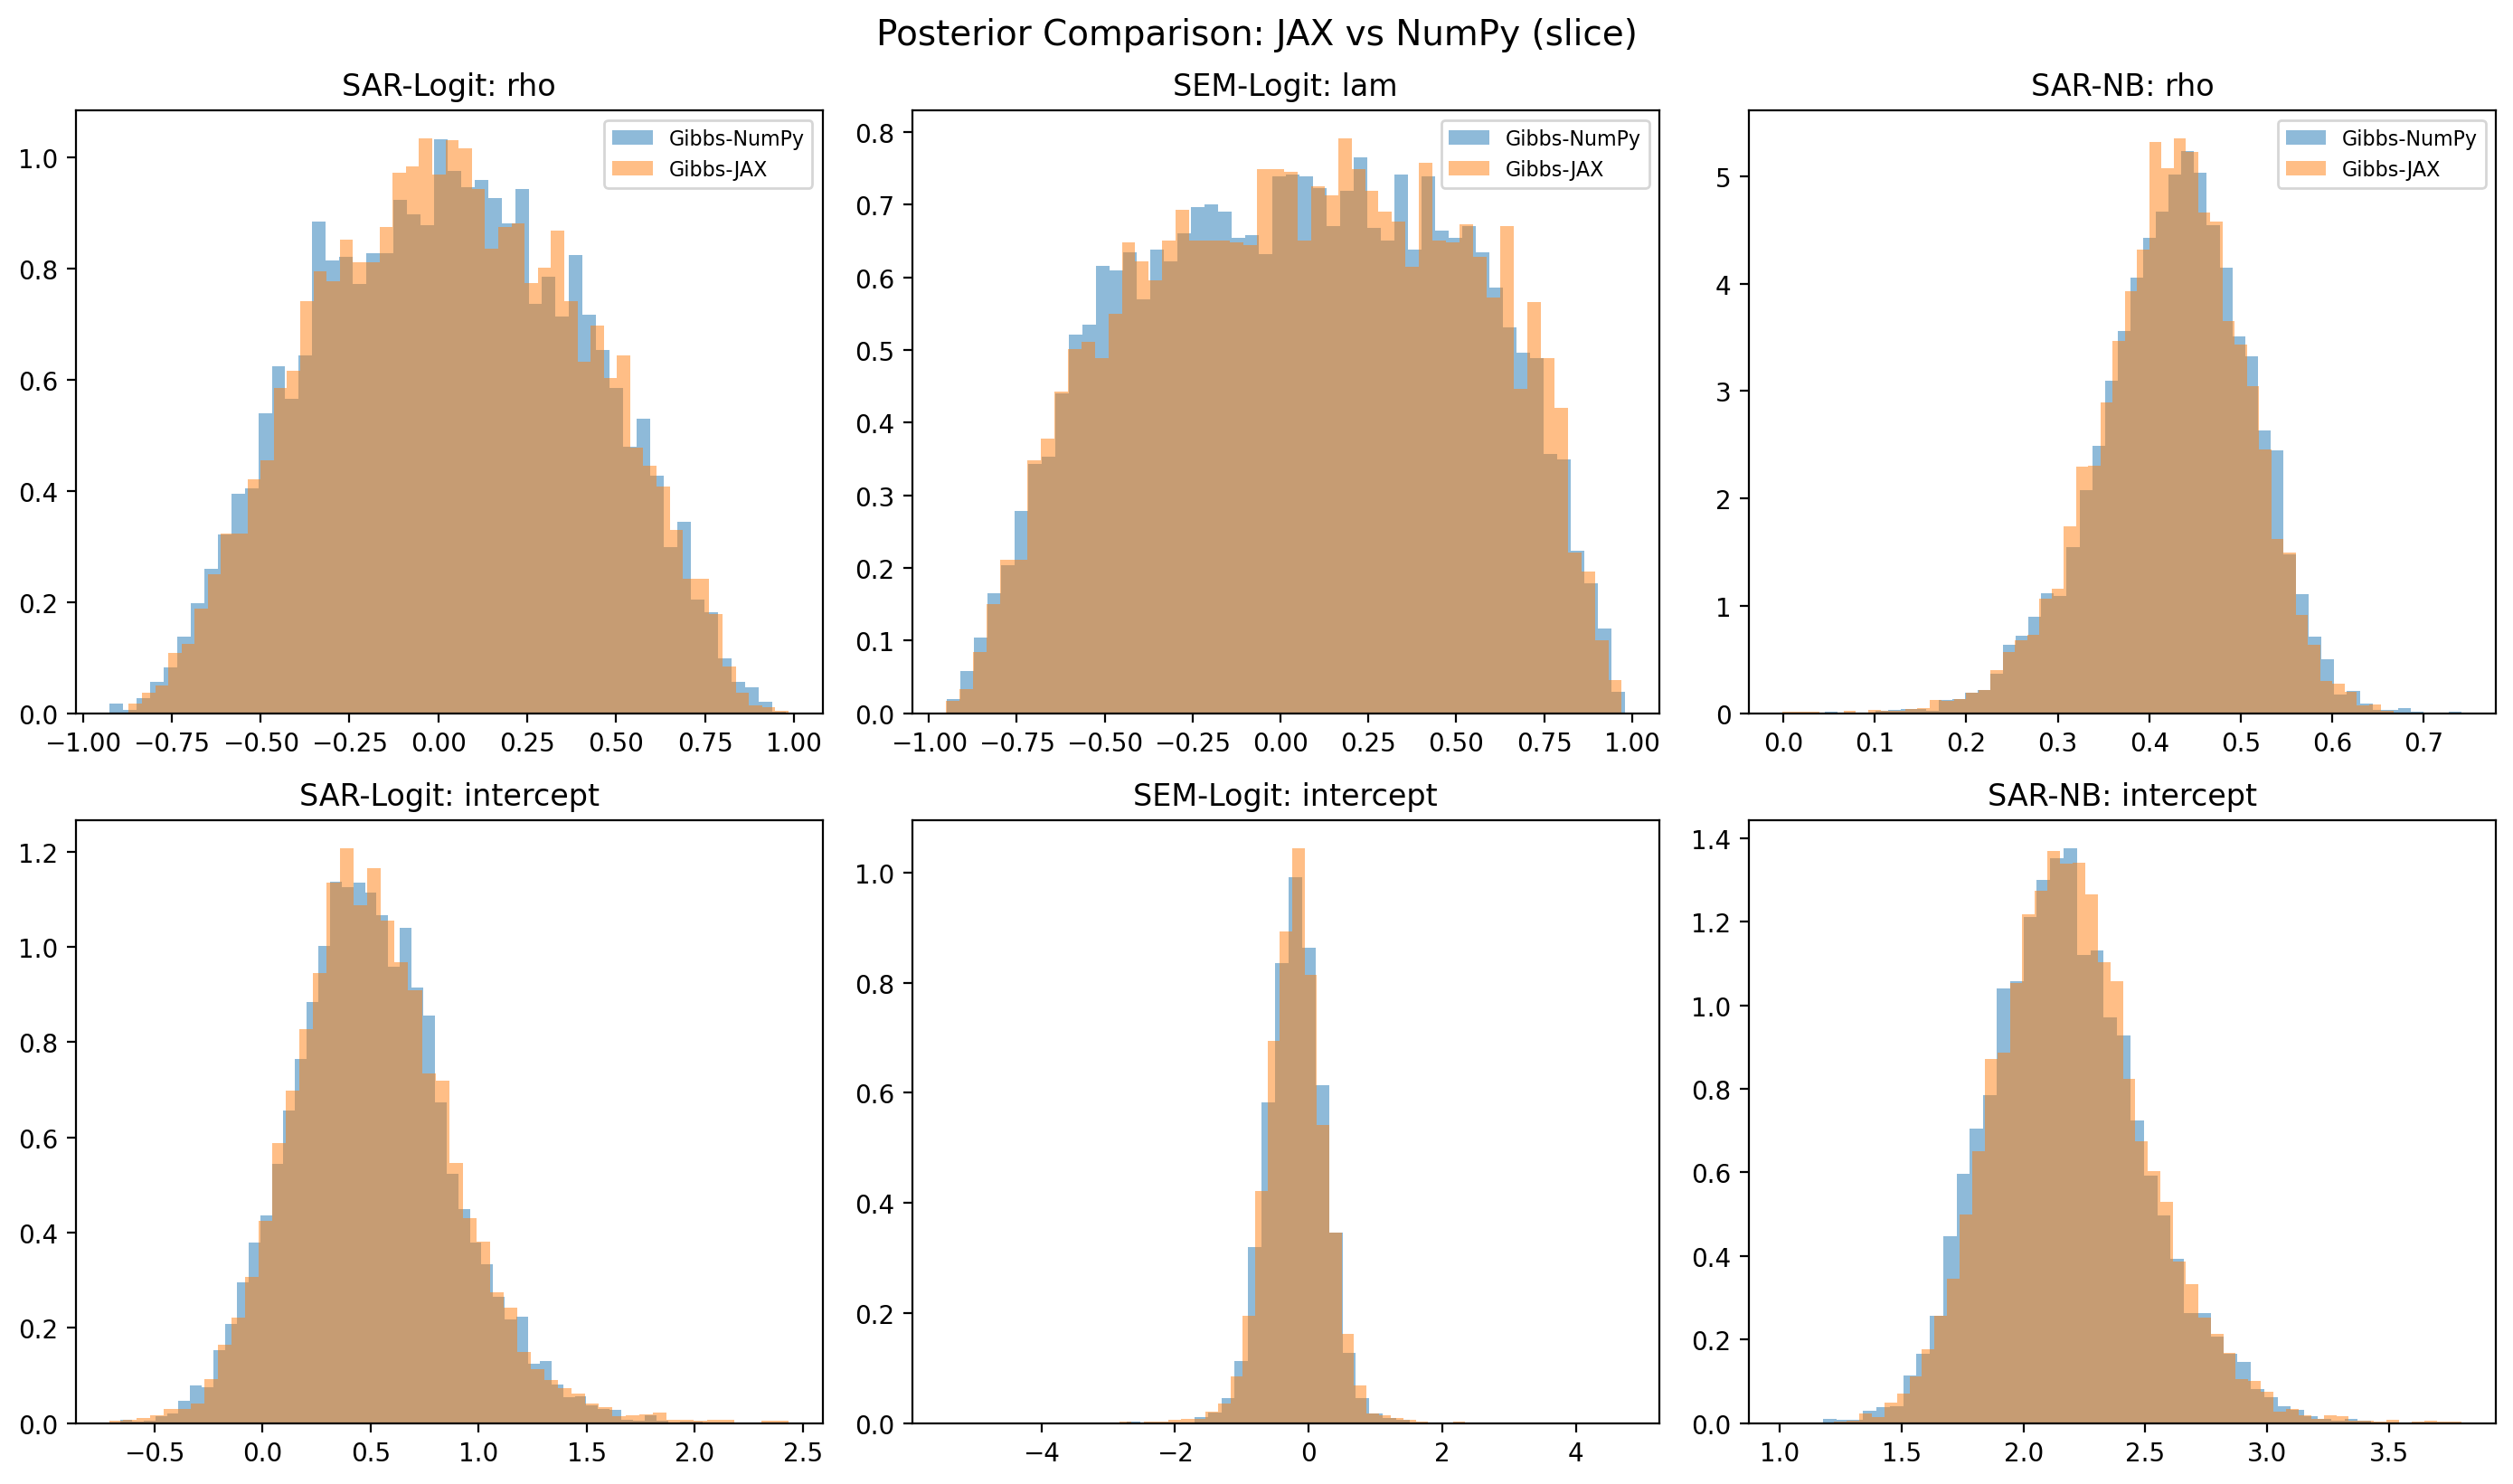

In [9]:
# Re-fit all models and store idatas for comparison plots
idatas = {}
for model_name, ModelClass, y, X in models_and_data:
    idatas[model_name] = {}
    for config_name, config in configs.items():
        model = ModelClass(y=y, X=X, W=W)
        try:
            idata = model.fit(**config)
            idatas[model_name][config_name] = idata
        except Exception:
            pass

# Plot comparison for each model
spatial_param_map = {"SAR-Logit": "rho", "SEM-Logit": "lam", "SAR-NB": "rho"}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col, model_name in enumerate(["SAR-Logit", "SEM-Logit", "SAR-NB"]):
    param = spatial_param_map[model_name]
    for row, param_name in enumerate([param, "beta"]):
        ax = axes[row, col]
        for config_name in configs:
            if config_name in idatas.get(model_name, {}):
                idata = idatas[model_name][config_name]
                if param_name == "beta":
                    # Plot intercept (first coefficient)
                    samples = idata.posterior["beta"].values[:, :, 0].flatten()
                else:
                    samples = idata.posterior[param_name].values.flatten()
                ax.hist(samples, bins=50, alpha=0.5, density=True, label=config_name)
        ax.set_title(
            f"{model_name}: {param_name if param_name != 'beta' else 'intercept'}"
        )
        if row == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle("Posterior Comparison: JAX vs NumPy (slice)", y=1.02, fontsize=14)
plt.show()

## 7. ESS per Second Comparison

Effective sample size per second measures sampling efficiency — higher is better. The JAX path's full-JIT compilation eliminates Python dispatch overhead, and the Krylov basis provides cheap density evaluations for the NB ρ-slice.

In [10]:
# Compute ESS/sec for the spatial parameter
ess_per_sec = []
for model_name in ["SAR-Logit", "SEM-Logit", "SAR-NB"]:
    param = spatial_param_map[model_name]
    for config_name in configs:
        if config_name in idatas.get(model_name, {}):
            idata = idatas[model_name][config_name]
            ess = float(az.summary(idata, var_names=[param]).loc[param, "ess_bulk"])
            elapsed = [
                r["elapsed_s"]
                for r in results
                if r["label"] == f"{model_name}/{config_name}"
            ]
            t = elapsed[0] if elapsed else 1.0
            ess_per_sec.append(
                {
                    "Model": model_name,
                    "Sampler": config_name,
                    "ESS_bulk": int(ess),
                    "Time (s)": t,
                    "ESS/sec": round(ess / t, 1),
                }
            )

ess_df = pd.DataFrame(ess_per_sec)
if len(ess_df) > 0:
    pivot_ess = ess_df.pivot(index="Model", columns="Sampler", values="ESS/sec")
    if "Gibbs-NumPy" in pivot_ess.columns and "Gibbs-JAX" in pivot_ess.columns:
        pivot_ess["JAX ESS/sec ratio"] = (
            pivot_ess["Gibbs-JAX"] / pivot_ess["Gibbs-NumPy"]
        )
    print("ESS per second for spatial parameter (ρ/λ):")
    display(pivot_ess.round(1))
else:
    print("No ESS data available.")

ESS per second for spatial parameter (ρ/λ):


Sampler,Gibbs-JAX,Gibbs-NumPy,JAX ESS/sec ratio
Model,,,
SAR-Logit,1213.9,923.1,1.3
SAR-NB,168.8,213.7,0.8
SEM-Logit,893.4,579.0,1.5


## 8. Scaling: Effect of n on JAX vs NumPy Time

How does wall-clock time scale with the number of spatial units? The JAX path uses dense LU (O(n³)) while NumPy uses CHOLMOD/CG sparse solves — the crossover depends on sparsity and problem size.

In [11]:
SCALE_DRAWS = 2000
SCALE_TUNE = 1000
SCALE_CHAINS = 2
SIDES = [5, 7, 10, 15]  # n = 25, 49, 100, 225

scale_results = []

scale_configs = {
    "Gibbs-NumPy": dict(
        sampler="gibbs",
        gibbs_method="factorize",
        n_jobs=-1,
        draws=SCALE_DRAWS,
        tune=SCALE_TUNE,
        chains=SCALE_CHAINS,
        random_seed=SEED,
        progressbar=False,
    ),
}
if HAS_JAX:
    scale_configs["Gibbs-JAX"] = dict(
        sampler="gibbs",
        gibbs_method="jax_dense",
        draws=SCALE_DRAWS,
        tune=SCALE_TUNE,
        chains=SCALE_CHAINS,
        random_seed=SEED,
        progressbar=False,
    )

for side in SIDES:
    n_s = side * side
    W_dense_s = make_rook_W(side)
    W_s = W_to_graph(W_dense_s)
    rng_s = np.random.default_rng(SEED)
    out_s = simulate_sar_logit(W=W_dense_s, rho=0.5, rng=rng_s)
    y_s, X_s = out_s["y"], out_s["X"]

    print(f"\nn = {n_s} (side={side})")
    for config_name, config in scale_configs.items():
        label = f"n={n_s}/{config_name}"
        model = SARSpatialLogit(y=y_s, X=X_s, W=W_s)
        try:
            result = profile_model(model, config, label)
            print(f"  {config_name}: {result['elapsed_s']:.1f}s")
            result["n"] = n_s
            result["sampler"] = config_name
            scale_results.append(result)
        except Exception as e:
            print(f"  {config_name}: FAILED ({e})")

print("\nScaling benchmark complete.")


n = 25 (side=5)
  Gibbs-NumPy: 8.7s
  Gibbs-JAX: 2.2s

n = 49 (side=7)
  Gibbs-NumPy: 9.1s
  Gibbs-JAX: 3.4s

n = 100 (side=10)
  Gibbs-NumPy: 10.2s
  Gibbs-JAX: 6.5s

n = 225 (side=15)
  Gibbs-NumPy: 10.6s
  Gibbs-JAX: 16.1s

Scaling benchmark complete.


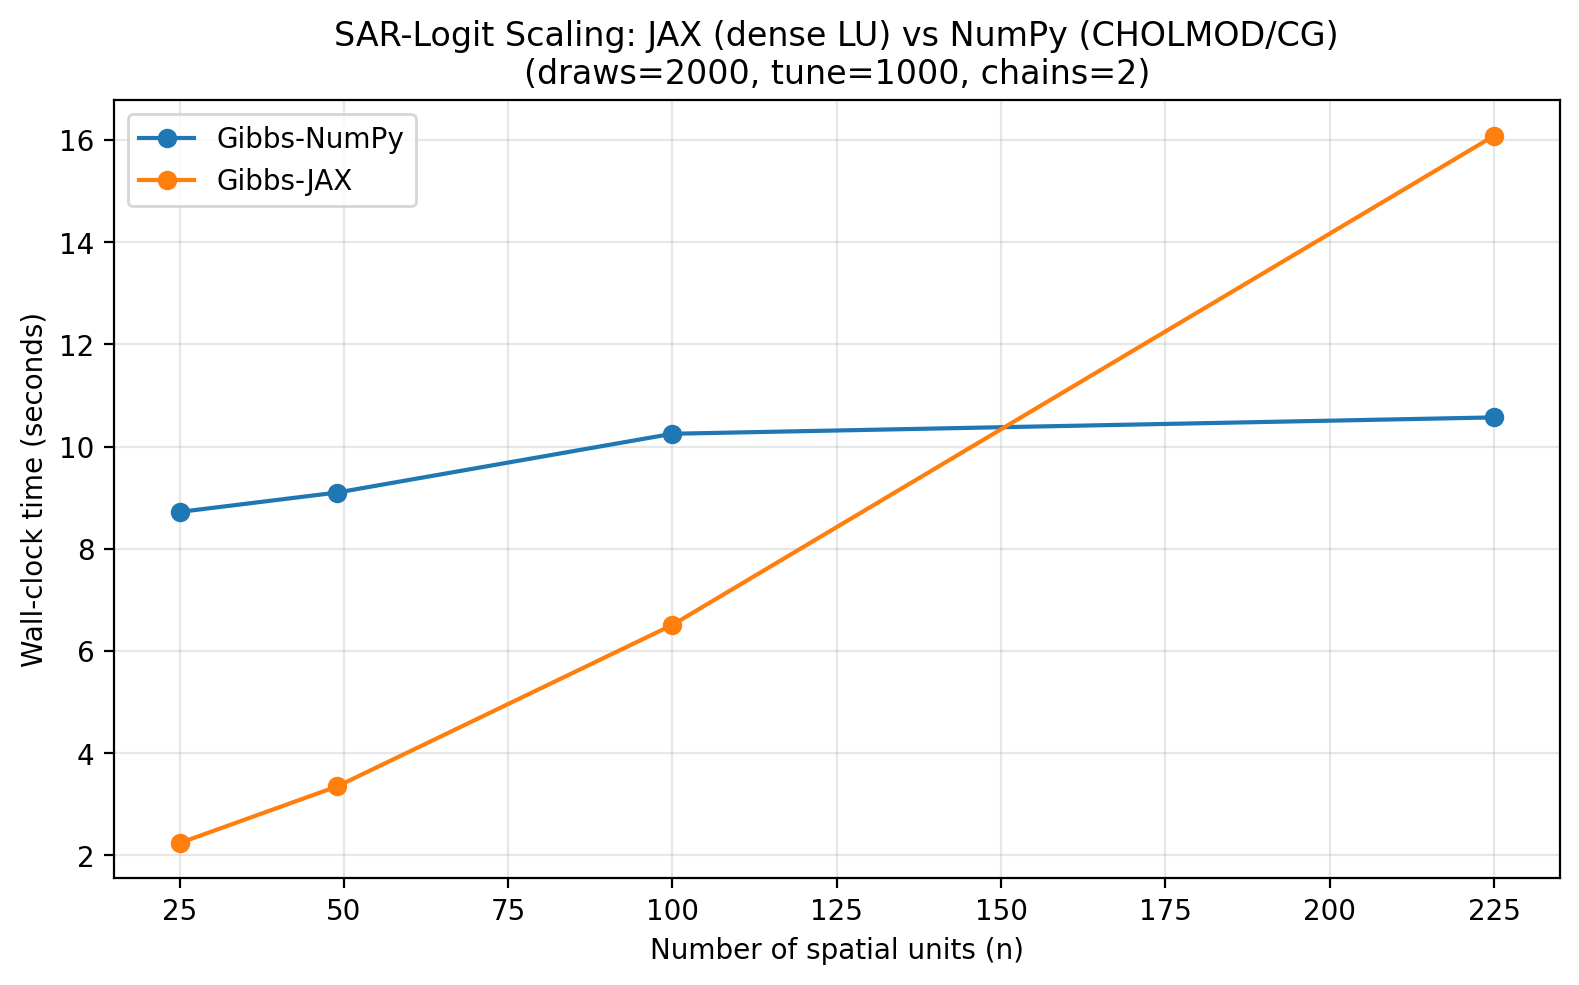

In [12]:
# Plot scaling results
if scale_results:
    scale_df = pd.DataFrame(scale_results)
    fig, ax = plt.subplots(figsize=(8, 5))
    for sampler in scale_df["sampler"].unique():
        sub = scale_df[scale_df["sampler"] == sampler].sort_values("n")
        ax.plot(sub["n"], sub["elapsed_s"], marker="o", label=sampler)
    ax.set_xlabel("Number of spatial units (n)")
    ax.set_ylabel("Wall-clock time (seconds)")
    ax.set_title(
        f"SAR-Logit Scaling: JAX (dense LU) vs NumPy (CHOLMOD/CG)\n"
        f"(draws={SCALE_DRAWS}, tune={SCALE_TUNE}, chains={SCALE_CHAINS})"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No scaling results to plot.")

## 9. Summary

Both the NumPy and JAX Gibbs backends use **slice sampling** for the ρ/λ update. The key difference is the linear algebra backend:

### NumPy (`factorize`): CHOLMOD/CG sparse solves

- Factorises $A^T A = I - \rho(W+W^T) + \rho^2 W^T W$ via CHOLMOD (when available) or SuperLU.
- Uses CG iterative solves when CHOLMOD is unavailable or n is large.
- Exploits sparsity: O(nnz^{1.5}) for CHOLMOD, O(K·nnz) for CG.
- Best for large, sparse W where the dense O(n³) cost is prohibitive.

### JAX (`jax_dense`): Dense LU factorisation

- Factorises $A_\rho = I - \rho W$ via `jax.scipy.linalg.lu_factor` once per sweep.
- Builds the Krylov basis with (m+1) `lu_solve` calls, then evaluates slice candidates via Horner — O(m·n·k) per candidate.
- Full JIT compilation: the entire Gibbs step (including the Krylov build + slice sampling) is a single XLA kernel.
- Best for small-to-medium problems (n ≤ ~2000 on CPU) where JIT eliminates Python dispatch overhead.

### Why slice sampling everywhere?

MALA was tried for both logit and NB JAX paths but was significantly slower:

- **Logit**: MALA requires `jax.value_and_grad` through `jnp.linalg.solve`, which traces through Cholesky+solve backward (~3× forward cost), called twice per step (current + proposed). This made JAX logit 3.6× slower than NumPy. Slice sampling avoids gradients entirely — each candidate needs only a forward density evaluation.
- **NB reduced form**: Same autodiff bottleneck — `jnp.linalg.solve` backward pass is O(n³), making MALA 25× slower than NumPy. The Krylov basis provides cheap density evaluations for slice sampling.

### Common features

- **Krylov basis** (NB only): Both backends build $V_j = A_\rho^{-1}(W V_{j-1})$ at the current ρ and evaluate U(ρ) via Horner for each slice candidate.
- **No logdet** (NB reduced form): The reduced form's β-marginalised ρ density does not include log|I−ρW| — it cancels when β is integrated out.
- **Intercept reparameterisation** (NB): $\delta_0 = \beta_0/(1-\rho)$ breaks the ρ–β₀ posterior correlation that causes ESS collapse at high ρ.